In [110]:
import datacube

import geopandas as gpd
from datetime import datetime, timedelta
import pandas as pd
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from affine import Affine
from datacube.utils.geometry import CRS
from datacube.utils.cog import write_cog
import rasterio.features
from pathlib import Path
from shapely.geometry import shape
from tempfile import TemporaryDirectory
from skimage import morphology
from scipy import ndimage
import sys
sys.path.insert(1, '../../Temp_branch/dea-notebooks/Tools')
from dea_tools.datahandling import load_ard
from dea_tools.plotting import rgb, display_map
from dea_tools.bandindices import calculate_indices
from dea_tools.dask import create_local_dask_cluster
from dea_tools.spatial import xr_vectorize

# Create local dask cluster to improve data load time
client = create_local_dask_cluster(return_client=True)

/env/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 39999 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/cate.kooymans@ga.gov.au/proxy/39999/status,
Dashboard: /user/cate.kooymans@ga.gov.au/proxy/39999/status,Workers: 1
Total threads: 62,Total memory: 456.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:42023,Workers: 1
Dashboard: /user/cate.kooymans@ga.gov.au/proxy/39999/status,Total threads: 62
Started: Just now,Total memory: 456.00 GiB
Comm: tcp://127.0.0.1:33925,Total threads: 62
Dashboard: /user/cate.kooymans@ga.gov.au/proxy/34597/status,Memory: 456.00 GiB
Nanny: tcp://127.0.0.1:37537,


In [111]:
dc = datacube.Datacube(app="Burnt_area_mapping")

In [112]:
def display_geometry_on_map(geom, zoom_bias=0):
    """
    Plots a datacube.utils.geometry.Geometry object on a folium map.

    Parameters
    ----------
    geom : datacube.utils.geometry.Geometry
        A geometry object to plot.
    zoom_bias : int or float
        Optional zoom adjustment.

    Returns
    -------
    folium.Map
        Interactive map with the geometry overlay.
    """
    import folium
    import numpy as np
    from pyproj import Transformer


    # Transform geometry to EPSG:4326 if needed
    if geom.crs.to_epsg() != 4326:
        geom = geom.to_crs('EPSG:4326')

    # Prepare list of polygons
    polygons = []
    if geom.geom.geom_type == 'Polygon':
        polygons.append(list(geom.geom.exterior.coords))
    elif geom.geom.geom_type == 'MultiPolygon':
        for poly in geom.geom.geoms:
            polygons.append(list(poly.exterior.coords))
    else:
        raise ValueError(f"Unsupported geometry type: {geom.geom.geom_type}")

    # Flatten all coordinates for center calculation
    all_coords = [coord for poly in polygons for coord in poly]
    lat_lon_coords = [(y, x) for x, y in all_coords]  # Folium expects (lat, lon)

    # Calculate center and zoom
    lats, lons = zip(*lat_lon_coords)
    center = [np.mean(lats), np.mean(lons)]
    zoom_level = 10 + zoom_bias

    # Create map
    m = folium.Map(location=center, zoom_start=zoom_level,
                   tiles="http://mt1.google.com/vt/lyrs=y&z={z}&x={x}&y={y}",
                   attr="Google")

    # Add each polygon to the map
    for poly_coords in polygons:
        lat_lon_poly = [(y, x) for x, y in poly_coords]
        folium.Polygon(locations=lat_lon_poly, color="blue", fill=True, fill_opacity=0.4).add_to(m)

    # Add lat-lon popup
    folium.LatLngPopup().add_to(m)

    return m


<Axes: >

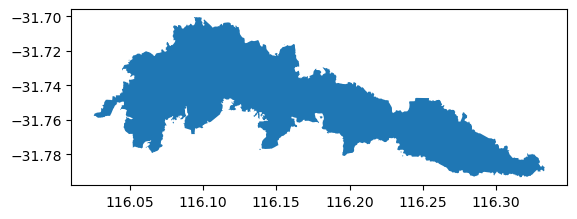

In [113]:
#open burn polygon
polygon_path = 'burn_polygons/wooroloo_WA_2021.shp'
# gdata1/projects/Hazards/burn_severity/extent_polygons/Buji_bim.shp
# Hazards/Burn_severity/burn_polygons/mystery_WA.shp
# Hazards/Burn_severity/burn_polygons/Adaminaby_complex.shp


poly = gpd.read_file(polygon_path)
poly.plot()

In [114]:
try:
    if len(poly) > 1:
        poly = poly.dissolve(by='fire_id')
        #disolve by fire id

except TypeError as e:
    pass
 

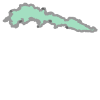

In [115]:
# Specifying coordinate reference system of the polygon.
gpgon = datacube.utils.geometry.Geometry(poly.geometry[0], crs=poly.crs)
gpgon

In [116]:
display_geometry_on_map(gpgon)

In [117]:
poly

,OBJECTID,fire_id,fire_name,ignition_d,capture_da,extinguish,fire_type,ignition_c,capt_metho,area_ha,perim_km,state,agency,Shape__Are,Shape__Len,geometry
0,83507,BF 2020 PHS 048,Wooroloo,2021-02-01,None,None,Unknown,None,Air intelligence GPS,10750,157,WA (Western Australia),WA DFES,0.010398,1.295704,"MULTIPOLYGON (((116.07934 -31.76147, 116.07958..."


In [118]:
# Fire event date

fire_date = str(poly.ignition_d[0])

try:
    extinguish_date = str(poly.extinguish[0])
except AttributeError as e:
    print('no estinguish date')

#find year for landcover data load

month_number = int(fire_date[5:7])
if month_number >= 10:
    landcover_year = fire_date[0:4]

else:
    landcover_year = str(int(fire_date[0:4]) - 1)

name = poly.fire_name[0]
print(landcover_year)

2020


In [119]:
# fire_date = '2016-02-10' #manually set fire date for mater behavior ananlysis
# extinguish_date = '2019-12-21'

In [120]:
#Harcoding in WA's buffers, pre-immage witin 50 days before, post fire is 60 days after

# Calculate the start and end date for baseline data load
start_date_pre = datetime.strftime(
    ((datetime.strptime(fire_date, '%Y-%m-%d')) - timedelta(days=50)), '%Y-%m-%d')
end_date_pre = datetime.strftime(
    ((datetime.strptime(fire_date, '%Y-%m-%d')) - timedelta(days=1)),
    '%Y-%m-%d')

# Calculate start end date for post fire data load
if extinguish_date == 'None':
    #if not extinguish date given assume 15 days
    start_date_post = datetime.strftime(
        ((datetime.strptime(fire_date, '%Y-%m-%d')) + timedelta(days=15)),
        '%Y-%m-%d')
else:
    #start date for post fire data load is extinguish date
    start_date_post = extinguish_date

#TO DO decide what our post fire max timeframe will be
end_date_post = datetime.strftime(
    ((datetime.strptime(start_date_post, '%Y-%m-%d')) + timedelta(days=60)),
    '%Y-%m-%d')

In [121]:
print(start_date_pre, end_date_pre)

2020-12-13 2021-01-31


In [122]:
resolution = (-10, 10)
measurements = ['nbart_blue', 'nbart_green', 'nbart_red',
                'nbart_nir_1','nbart_nir_2', 'nbart_swir_2','nbart_swir_3','oa_nbart_contiguity','oa_s2cloudless_mask']

output_crs = 'EPSG:3577'

In [123]:
# Load all data in baseline period available from ARD data
baseline = load_ard(dc=dc,
                        products=['ga_s2am_ard_3', 'ga_s2bm_ard_3','ga_s2cm_ard_3'],
                        geopolygon=gpgon,
                        cloud_mask = 's2cloudless',
                        # x=study_area_lon,
                        # y=study_area_lat,
                        time=(start_date_pre, end_date_pre),
                        measurements=measurements,
                        min_gooddata=0.99, #we want no clouds for the pre-fire image
                        output_crs=output_crs,
                        resolution=resolution,
                        group_by='solar_day',
                        dask_chunks= {"x": 2048, "y": 2048})

if baseline.time.size == 0:
    #try load again with less strict controls on clouds
    baseline = load_ard(dc=dc,
                        products=['ga_s2am_ard_3', 'ga_s2bm_ard_3','ga_s2cm_ard_3'],
                        geopolygon=gpgon,
                        cloud_mask = 's2cloudless',
                        # x=study_area_lon,
                        # y=study_area_lat,
                        time=(start_date_pre, end_date_pre),
                        measurements=measurements,
                        min_gooddata=0.90, #we want no clouds for the pre-fire image
                        output_crs=output_crs,
                        resolution=resolution,
                        group_by='solar_day',
                        dask_chunks= {"x": 2048, "y": 2048})


# (-1 is the most recent image from the stack)
closest_Bl = baseline.isel(time=-1)

debug_layer_blank = xr.ones_like(closest_Bl.nbart_red)

Finding datasets
    ga_s2am_ard_3
    ga_s2bm_ard_3
    ga_s2cm_ard_3
Counting good quality pixels for each time step using s2cloudless
Filtering to 9 out of 10 time steps with at least 99.0% good quality pixels
Applying s2cloudless pixel quality/cloud mask
Returning 9 time steps as a dask array


In [124]:
# rgb(closest_Bl, bands=['nbart_swir_2', 'nbart_nir_2', 'nbart_green'])

In [125]:
#Calculate NBR
pre_nbr = calculate_indices(closest_Bl, 
                             index='NBR', 
                             collection='ga_s2_3', 
                             drop=True)

Dropping bands ['nbart_blue', 'nbart_green', 'nbart_red', 'nbart_nir_1', 'nbart_nir_2', 'nbart_swir_2', 'nbart_swir_3', 'oa_nbart_contiguity', 'oa_s2cloudless_mask']


In [126]:
# Load post-fire data from all Sentinel 2 satellites
post = load_ard(dc=dc,
                products=['ga_s2am_ard_3', 'ga_s2bm_ard_3','ga_s2cm_ard_3'],
                geopolygon=gpgon,
                cloud_mask = 's2cloudless',
                # x=study_area_lon,
                # y=study_area_lat,
                time=(start_date_post, end_date_post),
                min_gooddata=0.90,
                measurements=measurements,
                output_crs=output_crs,
                resolution=resolution,
                group_by='solar_day',
                dask_chunks= {"x": 2048, "y": 2048})

Finding datasets
    ga_s2am_ard_3
    ga_s2bm_ard_3
    ga_s2cm_ard_3
Counting good quality pixels for each time step using s2cloudless
Filtering to 7 out of 12 time steps with at least 90.0% good quality pixels
Applying s2cloudless pixel quality/cloud mask
Returning 7 time steps as a dask array


In [127]:
# rgb(post, col='time', bands=['nbart_swir_2', 'nbart_nir_2', 'nbart_green'])

In [128]:

#calculate NBR for post fire
post_nbr = calculate_indices(post, 
                             index='NBR', 
                             collection='ga_s2_3', 
                             drop=True)

#calculate MINIMUM nbr in time stack
max_nbr = post_nbr.min('time')

Dropping bands ['nbart_blue', 'nbart_green', 'nbart_red', 'nbart_nir_1', 'nbart_nir_2', 'nbart_swir_2', 'nbart_swir_3', 'oa_nbart_contiguity', 'oa_s2cloudless_mask']


In [129]:
#calculate the delta NBR

deltaNBR =  pre_nbr - max_nbr

In [130]:
landcover = dc.load(
                product='ga_ls_landcover_class_cyear_3',
                geopolygon=gpgon,
                time=(landcover_year),
                output_crs=output_crs,
                resolution=resolution,
                group_by='solar_day',
                dask_chunks= {"x": 2048, "y": 2048})
landcover = landcover.isel(time=0) 

In [131]:
#remove time dimention

grass_class = [3, 14, 15, 16, 17, 18, 21, 32, 33, 34, 35, 36, 39, 50, 51, 52, 53, 54, 57, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 94, 95, 96, 97]
#these are the land Cover classes that are grass dominated

grass_mask = xr.zeros_like(landcover.level4)

for x in grass_class:
    x_pixels = (landcover.level4 == x ) * 1

    grass_mask = grass_mask + x_pixels

In [132]:
# apply thesholds to get severity classes
#the different severity classes are labled by stacking the extents together

low = (deltaNBR >= 0.1) * 2
medium = (deltaNBR >= 0.27) * 1
high = (deltaNBR >= 0.44) * 1
Very_high = (deltaNBR >= 0.66) * 1

severity_woody = (low + medium + high + Very_high) #combine the woody severity classes
severity_woody = (severity_woody.NBR.where(grass_mask== 0, 0))
#mask woody burn severity by grass extent

In [133]:
severity_grass = grass_mask.where(deltaNBR.NBR >= 0.1, 0)
#this gives us where both grass and burnt are true = grass burn extent.

severity = severity_woody + severity_grass
#combine woody and grass burn classes

In [134]:
# severity.plot()

The above gives us our severity classes. next steps is to determine 1) water extent 2) cloud and 3)contiguity errors. then apply those to severity as a 'no data class'

In [135]:
#calculate NBR for post fire
post_MNDWI = calculate_indices(post, 
                             index='MNDWI', 
                             collection='ga_s2_3', 
                             drop=True)

max_MNDWI = post_MNDWI.max('time')
# max_MNDWI.MNDWI.plot()

post_water = debug_layer_blank.where(max_MNDWI.MNDWI > 0, 0) #define water extent
#  #find the wettest observation per pixel


Dropping bands ['nbart_blue', 'nbart_green', 'nbart_red', 'nbart_nir_1', 'nbart_nir_2', 'nbart_swir_2', 'nbart_swir_3', 'oa_nbart_contiguity', 'oa_s2cloudless_mask']


In [136]:
#generate de-bug layer (and mask ^ result if requiered)
# mask for pre-fire cloud and and add that to de-bug

new_debug = post_water + (debug_layer_blank.where(closest_Bl.oa_s2cloudless_mask == 2, 0))*10 #add cloud to debug 

#mask for persistant post-fire cloud
#first remove contiguity from cloudmask
post_cloud = post.oa_s2cloudless_mask.where(post.oa_s2cloudless_mask >= 1, 1)
persistant_cloud = post_cloud.min('time') #find any pixels that have had no clear observation accross stack

new_debug = new_debug + (debug_layer_blank.where(persistant_cloud == 2, 0))*100 #add post-fire cloud to debug


In [137]:
#now contiguity
#pre-fire contiguity

new_debug = new_debug + (debug_layer_blank.where(closest_Bl.oa_nbart_contiguity != 1, 0))*1000

#post-fire contiguity
post_contiguity = post.oa_nbart_contiguity.where(post.oa_nbart_contiguity == 1, 0) #turns all non 1 values to 0
persistant_cont = post_contiguity.max('time') #find maximum contiguity value over stack

new_debug = new_debug + (debug_layer_blank.where(persistant_cont != 1, 0))*10000 # add post fire contiguity to de-bug


In [138]:
# new_debug.plot(cmap='tab20', vmax=100) #it goes up to 10000 but you can't see anything if you iclude that in visualisation range

In [139]:
Severity = severity.where(new_debug ==0, 6) #ensure dataclasses from de-bug are no data 

If you want to save the geotiff output uncomment the below

In [140]:
# write_cog(severity.compute(), fname= 'results/burn_severity_water_behavior_test.tif')

In [141]:
# convert to vectors
severity_vectors = xr_vectorize(severity, attribute_col='severity',  crs=output_crs)

#reproject to EPSG 4283
severity_vectors = severity_vectors.to_crs('EPSG:4283')

In [142]:
#clip to polygon
cliped_severity_vectors = severity_vectors.clip(poly)


In [143]:
#dissolve to join all polygons with same severity classes
aggrigated_severity = cliped_severity_vectors.dissolve(by='severity')

In [144]:
# give output polygons the extent polygon's attributes

aggrigated_severity['fire_id'] = poly.fire_id[0]
aggrigated_severity['fire_name'] = poly.fire_name[0]
aggrigated_severity['ignition_d'] = poly.ignition_d[0]
aggrigated_severity['extinguish'] = poly.extinguish[0]

In [145]:
#Save polygons to file
aggrigated_severity.to_file(f'results/burn_severity_polygons{name}.shp')

In [150]:
#save de-bug layer
# write_cog(new_debug.compute(), fname= f'results/test_debug_layer_2{name}.tif')

#save severity as geotif if you want
# write_cog(severity.compute(), fname= 'results/burn_severity_water_behavior_test.tif')

#save first post-fire observation for validatio
write_cog(post.isel(time=0).to_array().compute(), fname= f'results/s2_postfire_{name}.tif')

PosixPath('results/s2_postfire_Wooroloo.tif')

In [149]:
post.isel(time=0).to_array()

<xarray.DataArray (variable: 9, y: 914, x: 2907)> Size: 96MB
dask.array<stack, shape=(9, 914, 2907), dtype=float32, chunksize=(1, 914, 2048), chunktype=numpy.ndarray>
Coordinates:
    time         datetime64[ns] 8B 2021-02-20T02:26:20.269245
  * y            (y) float64 7kB -3.547e+06 -3.547e+06 ... -3.556e+06 -3.556e+06
  * x            (x) float64 23kB -1.496e+06 -1.496e+06 ... -1.467e+06
    spatial_ref  int32 4B 3577
  * variable     (variable) object 72B 'nbart_blue' ... 'oa_s2cloudless_mask'
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref